In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/knowledgelovers/fish-yolo/README.md
/kaggle/input/datasets/knowledgelovers/fish-yolo/data.yaml
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191114_054824_png.rf.de27427885852de5d514ba7636df9baa.txt
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191016_064153_png.rf.7b8626b1a87306010b4186f7ef8afb54.txt
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191115_063524_png.rf.f85f5f72f7e3fac1605c920f9aaf424a.txt
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191112_053125_png.rf.dc301f6f92188dce4ec02323e6809529.txt
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191003_064634_png.rf.eaca02f79b135f2a90d8116a9ab0bf84.txt
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191113_055841_png.rf.4f49b41831b3b0effe811c731dc0316c.txt
/kaggle/input/datasets/knowledgelovers/fish-yolo/valid/labels/IMG_20191111_062049_png.rf.08696e737fb80d0ffb97a8d2018e2de9.txt


In [2]:
import os
import shutil
from PIL import Image

# ---------- SOURCE DATA ----------
SRC_IMG_DIR = "/kaggle/input/datasets/knowledgelovers/fish-yolo/train/images"
SRC_LABEL_DIR = "/kaggle/input/datasets/knowledgelovers/fish-yolo/train/labels"

# ---------- READY DATASET ----------
DST_BASE = "data/ready"
DST_IMG_DIR = os.path.join(DST_BASE, "images")
DST_LABEL_DIR = os.path.join(DST_BASE, "labels")

os.makedirs(DST_IMG_DIR, exist_ok=True)
os.makedirs(DST_LABEL_DIR, exist_ok=True)

# ---------- STATS ----------
stats = {
    "total_images": 0,
    "copied": 0,
    "corrupt_images": 0,
    "missing_labels": 0,
    "empty_labels": 0
}

# ---------- IMAGE CHECK ----------
def is_image_valid(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

clas = set();

# ---------- ITERATE ACTUAL FILES ----------
for img_file in os.listdir(SRC_IMG_DIR):
    img_path = os.path.join(SRC_IMG_DIR, img_file)

    if not os.path.isfile(img_path):
        continue

    stats["total_images"] += 1

    name, _ = os.path.splitext(img_file)
    label_path = os.path.join(SRC_LABEL_DIR, name + ".txt")
    with open( label_path, "r") as f:
        for line in f:
           c, x,y,w,h = map(float, line.strip().split())

           clas.add(c);

    # 1. Image corruption check
    if not is_image_valid(img_path):
        stats["corrupt_images"] += 1
        continue

    # 2. Label existence
    if not os.path.exists(label_path):
        stats["missing_labels"] += 1
        continue

    # 3. Label size check
    if os.path.getsize(label_path) == 0:
        stats["empty_labels"] += 1
        continue

    # 4. Copy to READY dataset
    shutil.copy2(img_path, os.path.join(DST_IMG_DIR, img_file))
    shutil.copy2(label_path, os.path.join(DST_LABEL_DIR, name + ".txt"))

    stats["copied"] += 1

# ---------- SUMMARY ----------
print("\n====== READY DATASET CREATED ======")
for k, v in stats.items():
    print(f"{k.replace('_',' ').title():<20}: {v}")
print("==================================")


====== READY DATASET CREATED ======
Total Images        : 1400
Copied              : 1397
Corrupt Images      : 0
Missing Labels      : 0
Empty Labels        : 3


In [7]:
import os
import shutil
from PIL import Image

# ---------- SOURCE DATA ----------
SRC_IMG_DIR = "/kaggle/input/datasets/knowledgelovers/fish-yolo/test/images"
SRC_LABEL_DIR = "/kaggle/input/datasets/knowledgelovers/fish-yolo/test/labels"

# ---------- READY DATASET ----------
DST_BASE = "data/test"
DST_IMG_DIR = os.path.join(DST_BASE, "images")
DST_LABEL_DIR = os.path.join(DST_BASE, "labels")

os.makedirs(DST_IMG_DIR, exist_ok=True)
os.makedirs(DST_LABEL_DIR, exist_ok=True)

# ---------- STATS ----------
stats = {
    "total_images": 0,
    "copied": 0,
    "corrupt_images": 0,
    "missing_labels": 0,
    "empty_labels": 0
}

# ---------- IMAGE CHECK ----------
def is_image_valid(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

clas = set();

# ---------- ITERATE ACTUAL FILES ----------
for img_file in os.listdir(SRC_IMG_DIR):
    img_path = os.path.join(SRC_IMG_DIR, img_file)

    if not os.path.isfile(img_path):
        continue

    stats["total_images"] += 1

    name, _ = os.path.splitext(img_file)
    label_path = os.path.join(SRC_LABEL_DIR, name + ".txt")
    with open( label_path, "r") as f:
        for line in f:
           c, x,y,w,h = map(float, line.strip().split())

           clas.add(c);

    # 1. Image corruption check
    if not is_image_valid(img_path):
        stats["corrupt_images"] += 1
        continue

    # 2. Label existence
    if not os.path.exists(label_path):
        stats["missing_labels"] += 1
        continue

    # 3. Label size check
    if os.path.getsize(label_path) == 0:
        stats["empty_labels"] += 1
        continue

    # 4. Copy to READY dataset
    shutil.copy2(img_path, os.path.join(DST_IMG_DIR, img_file))
    shutil.copy2(label_path, os.path.join(DST_LABEL_DIR, name + ".txt"))

    stats["copied"] += 1

# ---------- SUMMARY ----------
print("\n====== READY DATASET CREATED ======")
for k, v in stats.items():
    print(f"{k.replace('_',' ').title():<20}: {v}")
print("==================================")


====== READY DATASET CREATED ======
Total Images        : 192
Copied              : 192
Corrupt Images      : 0
Missing Labels      : 0
Empty Labels        : 0


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00a 0:00:01


In [8]:

import torch
from ultralytics import YOLO


dataset_yaml = """
path: /kaggle/working/data/
train: ready
val: test
nc: 4
names: [0,1,2,3]
"""

with open("dataset.yaml", "w") as f:
    f.write(dataset_yaml)

model = YOLO("yolov8n.pt")  # or yolov8s.pt / yolov8m.pt

model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=448,
    batch=16,
 
)


Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x795b816ba330>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [9]:
model.save("detection.pt")


image 1/1 /kaggle/input/datasets/knowledgelovers/fish-test/412YOMx098L._AC.jpg: 384x448 2 1s, 5 2s, 6.4ms
Speed: 1.2ms preprocess, 6.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 448)


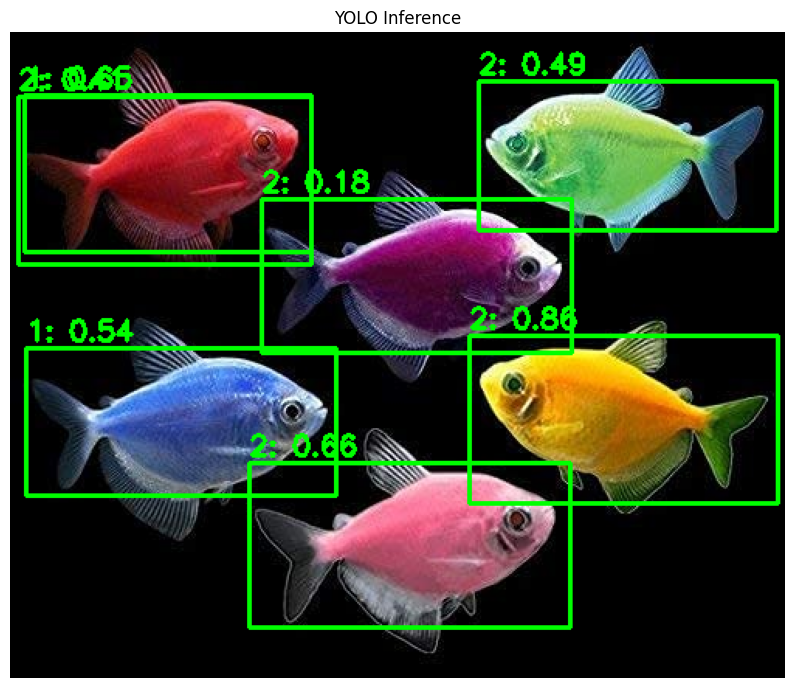

In [7]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

def visualize_inference(image_path, model_path="detection.pt", conf=0.1):
    # Load model
    model = YOLO(model_path)

    # Run inference
    results = model(image_path, conf=conf)

    # Read image (BGR)
    img = cv2.imread(image_path)
    assert img is not None, "Image not found"

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        print("No detections")
    else:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            score = float(box.conf[0])

            label = f"{cls}: {score:.2f}"

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                img, label, (x1, max(y1 - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2
            )

    # Convert BGR → RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("YOLO Inference")
    plt.show()

visualize_inference("/kaggle/input/datasets/knowledgelovers/fish-test/412YOMx098L._AC.jpg")
